In [1]:
# train_lfw_arcface_cpu.py
import math, argparse, time
import os, csv, json
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm import tqdm

# ----------------------------
# ArcFace head (classification)
# ----------------------------
class ArcMarginProduct(nn.Module):
    def __init__(self, in_feat, out_feat, s=64.0, m=0.50, easy_margin=False):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(out_feat, in_feat))
        nn.init.xavier_uniform_(self.weight)
        self.s = s
        self.m = m
        self.easy_margin = easy_margin
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, emb, label):
        emb = F.normalize(emb, p=2, dim=1)
        W = F.normalize(self.weight, p=2, dim=1)
        cosine = F.linear(emb, W).clamp(-1, 1)
        sine = torch.sqrt((1.0 - cosine ** 2).clamp(0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        onehot = torch.zeros_like(cosine)
        onehot.scatter_(1, label.view(-1, 1), 1.0)
        logits = onehot * phi + (1.0 - onehot) * cosine
        logits *= self.s
        return logits

# ----------------------------
# Backbone: ResNet-18 → embedding
# ----------------------------
class FaceNet(nn.Module):
    def __init__(self, embedding_dim=128, pretrained=False):
        super().__init__()
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT if pretrained else None
        )
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.embed = nn.Linear(in_features, embedding_dim, bias=False)
        self.bn = nn.BatchNorm1d(embedding_dim)

    def forward(self, x):
        x = self.backbone(x)
        x = self.embed(x)
        x = self.bn(x)
        return x

# ----------------------------
# Utilities
# ----------------------------
def set_seed(seed=42):
    import random
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

def build_transforms(img_size):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])

def _maybe_fix_nested_root(root):
    inner = Path(root) / "lfw-deepfunneled"
    if inner.exists() and inner.is_dir():
        subdirs = [p for p in inner.iterdir() if p.is_dir()]
        if len(subdirs) > 0:
            return str(inner)
    return root

def split_by_identity(dataset: ImageFolder, train_id_frac=0.8, min_images_per_id=2, seed=42):
    by_class = defaultdict(list)
    for idx, (_, cls) in enumerate(dataset.samples):
        by_class[cls].append(idx)

    valid_classes = [c for c, idxs in by_class.items() if len(idxs) >= min_images_per_id]
    if len(valid_classes) == 0:
        return [], [], [], []

    rng = np.random.default_rng(seed)
    rng.shuffle(valid_classes)
    split_point = max(1, int(len(valid_classes) * train_id_frac))
    train_classes = set(valid_classes[:split_point])
    val_classes   = set(valid_classes[split_point:]) or set(valid_classes[-1:])

    train_idx, val_idx = [], []
    for c, idxs in by_class.items():
        if c in train_classes: train_idx.extend(idxs)
        elif c in val_classes: val_idx.extend(idxs)
    return train_idx, val_idx, sorted(list(train_classes)), sorted(list(val_classes))

class RemapSubset(Dataset):
    """
    Pickle-safe dataset wrapper that:
      - selects a subset of ImageFolder by indices
      - remaps class ids via a provided dict (for train set)
    """
    def __init__(self, base: ImageFolder, indices, class_remap=None):
        self.base = base
        self.indices = list(indices)
        self.class_remap = class_remap  # dict old->new or None

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y = self.base[self.indices[i]]
        if self.class_remap is not None:
            y = self.class_remap[y]
        return x, y

def make_loaders(img_size=112, batch_size=64, root="./archive/lfw-deepfunneled",
                 train_id_frac=0.8, min_images_per_id=2, max_train_ids=None,
                 num_workers=0, seed=42):
    tfm = build_transforms(img_size)
    root = _maybe_fix_nested_root(root)
    full_dataset = ImageFolder(root=root, transform=tfm)
    if len(full_dataset) == 0:
        raise RuntimeError(f"No images under {root}")

    train_idx, val_idx, train_classes, val_classes = split_by_identity(
        full_dataset, train_id_frac=train_id_frac, min_images_per_id=min_images_per_id, seed=seed
    )

    # Optionally cap train identities
    if train_classes and max_train_ids is not None and len(train_classes) > max_train_ids:
        rng = np.random.default_rng(seed)
        keep = set(rng.choice(train_classes, size=max_train_ids, replace=False))
        train_idx = [i for i in train_idx if full_dataset.samples[i][1] in keep]
        train_classes = sorted(list(keep))

    if len(train_idx) == 0:
        # Fallback to random image split (so you can still run)
        print("[WARN] Identity split empty; falling back to random image split.")
        n_total = len(full_dataset)
        n_train = max(1, int(0.8 * n_total))
        n_val = n_total - n_train
        gen = torch.Generator().manual_seed(seed)
        train_subset, val_subset = torch.utils.data.random_split(full_dataset, [n_train, n_val], generator=gen)
        # Approximate num classes (not exact under random split)
        num_train_classes = len(full_dataset.classes)
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=False)
        val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False,num_workers=num_workers, pin_memory=False)
        print(f"[INFO] Random split: train images={len(train_subset)}, val images={len(val_subset)}")
        return full_dataset, train_loader, val_loader, num_train_classes, list(range(len(val_subset)))

    # Build class remap table (old id -> [0..num_train_classes-1])
    class_remap = {old: new for new, old in enumerate(train_classes)}
    train_set = RemapSubset(full_dataset, train_idx, class_remap=class_remap)
    val_set   = RemapSubset(full_dataset, val_idx, class_remap=None)

    print(f"[INFO] Train identities: {len(train_classes)} | Train images: {len(train_idx)}")
    print(f"[INFO] Val   identities: {len(val_classes)} | Val   images: {len(val_idx)}")

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=False)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=False)
    num_train_classes = len(train_classes)
    return full_dataset, train_loader, val_loader, num_train_classes, val_idx

# ---------- Build verification pairs from VAL identities ----------
def build_verification_pairs(dataset: ImageFolder, val_indices, n_pos=2000, n_neg=2000, seed=42):
    rng = np.random.default_rng(seed)
    by_class = defaultdict(list)
    for idx in val_indices:
        _, c = dataset.samples[idx]
        by_class[c].append(idx)

    classes = [c for c, idxs in by_class.items() if len(idxs) >= 2]
    if len(classes) == 0:
        raise RuntimeError("No validation identities with >=2 images to make positive pairs.")

    pos_pairs = []
    for _ in range(n_pos):
        c = rng.choice(classes)
        i1, i2 = rng.choice(by_class[c], size=2, replace=False)
        pos_pairs.append((i1, i2, 1))

    neg_pairs = []
    val_classes = list(by_class.keys())
    for _ in range(n_neg):
        c1, c2 = rng.choice(val_classes, size=2, replace=False)
        i1 = rng.choice(by_class[c1])
        i2 = rng.choice(by_class[c2])
        neg_pairs.append((i1, i2, 0))

    return pos_pairs + neg_pairs

@torch.no_grad()
def evaluate_verification(model, dataset: ImageFolder, pairs, batch_size=128, device="cpu"):
    model.eval()
    uniq = sorted({i for (i,_,_) in pairs} | {j for (_,j,_) in pairs})
    imgs = torch.stack([dataset[inx][0] for inx in uniq], dim=0).to(device)

    embs = []
    for s in range(0, len(imgs), batch_size):
        embs.append(model(imgs[s:s+batch_size]))
    embs = F.normalize(torch.cat(embs, dim=0), p=2, dim=1)

    idx_to_row = {idx: r for r, idx in enumerate(uniq)}
    sims, labels = [], []
    for i, j, lab in pairs:
        e1 = embs[idx_to_row[i]]
        e2 = embs[idx_to_row[j]]
        sims.append(float(torch.sum(e1 * e2)))
        labels.append(lab)

    sims = np.array(sims); labels = np.array(labels)
    auc = roc_auc_score(labels, sims)
    thresholds = np.linspace(-1, 1, 4001)
    accs = []
    for th in thresholds:
        preds = (sims >= th).astype(int)
        accs.append(accuracy_score(labels, preds))
    k = int(np.argmax(accs))
    return auc, accs[k], thresholds[k]

# ---------- Train / Eval ----------
def train_epoch(model, head, loader, optimizer, device):
    model.train(); head.train()
    loss_meter, correct, total = 0.0, 0, 0
    for imgs, targets in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device); targets = targets.to(device)
        optimizer.zero_grad()
        emb = model(imgs)
        logits = head(emb, targets)
        loss = F.cross_entropy(logits, targets)
        loss.backward(); optimizer.step()

        loss_meter += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == targets).sum().item()
        total += imgs.size(0)
    return loss_meter/total, correct/total

@torch.no_grad()
def eval_cls(model, head, loader, device):
    model.eval(); head.eval()
    loss_meter, correct, total = 0.0, 0, 0
    for imgs, targets in tqdm(loader, desc="Eval", leave=False):
        imgs = imgs.to(device)
        targets = targets.to(device)

        emb = model(imgs)
        # Instead of ArcFace head, do cosine sim against head.weight
        emb = F.normalize(emb, p=2, dim=1)
        W = F.normalize(head.weight, p=2, dim=1)
        logits = F.linear(emb, W) * head.s  # no margin

        # Clamp labels to head size to avoid OOB
        valid = targets < logits.shape[1]
        if valid.sum() == 0:
            continue
        logits = logits[valid]
        targets = targets[valid]

        loss = F.cross_entropy(logits, targets)
        loss_meter += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == targets).sum().item()
        total += imgs.size(0)
    return (loss_meter / max(1,total)), (correct / max(1,total))

In [2]:
def main():
    import os, csv, json  # local import to avoid changing your top cell
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-root", type=str, default="./archive/lfw-deepfunneled")
    parser.add_argument("--epochs", type=int, default=1)
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--img-size", type=int, default=96)
    parser.add_argument("--embedding-dim", type=int, default=128)
    parser.add_argument("--arc-s", type=float, default=64.0)
    parser.add_argument("--arc-m", type=float, default=0.50)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--pretrained-backbone", action="store_true")
    parser.add_argument("--max-train-ids", type=int, default=400)
    parser.add_argument("--pairs-per-type", type=int, default=2000)
    parser.add_argument("--min-images-per-id", type=int, default=2)
    parser.add_argument("--num-workers", type=int, default=0, help="Use 0 on Windows to avoid pickling issues")
    parser.add_argument("--out-prefix", type=str, default="lfw_run")  # NEW
    args = parser.parse_args()

    set_seed(args.seed)
    device = torch.device("cpu")

    # always defined
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "auc": []}

    dataset, train_loader, val_loader, num_train_classes, val_indices = make_loaders(
        img_size=args.img_size,
        batch_size=args.batch_size,
        root=args.data_root,
        train_id_frac=0.8,
        min_images_per_id=args.min_images_per_id,
        max_train_ids=args.max_train_ids,
        num_workers=args.num_workers,
        seed=args.seed
    )

    model = FaceNet(embedding_dim=args.embedding_dim, pretrained=args.pretrained_backbone).to(device)
    head  = ArcMarginProduct(in_feat=args.embedding_dim, out_feat=num_train_classes,
                             s=args.arc_s, m=args.arc_m).to(device)

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(head.parameters()),
        lr=args.lr, weight_decay=args.weight_decay
    )

    # verification pairs from VAL identities
    try:
        pairs = build_verification_pairs(
            dataset, val_indices,
            n_pos=args.pairs_per_type, n_neg=args.pairs_per_type,
            seed=args.seed
        )
        have_pairs = True
    except RuntimeError as e:
        print(f"[WARN] No verification pairs: {e}")
        have_pairs = False

    out_prefix = args.out_prefix
    metrics_csv = Path(f"{out_prefix}_metrics.csv")
    history_json = Path(f"{out_prefix}_history.json")
    ckpt_best = Path(f"{out_prefix}_best.pt")
    ckpt_last = Path(f"{out_prefix}_last.pt")

    best_auc = -float("inf")

    # write CSV header
    with metrics_csv.open("w", newline="") as f_csv:
        writer = csv.writer(f_csv)
        writer.writerow(["epoch","train_loss","train_acc","val_loss","val_acc","auc","best_acc","best_thr","seconds"])
        f_csv.flush()
        try: os.fsync(f_csv.fileno())
        except: pass

        for epoch in range(1, args.epochs + 1):
            t0 = time.time()
            tr_loss, tr_acc = train_epoch(model, head, train_loader, optimizer, device)
            va_loss, va_acc = eval_cls(model, head, val_loader, device)

            if have_pairs:
                auc, best_acc, best_th = evaluate_verification(
                    model, dataset, pairs, batch_size=max(64, args.batch_size), device=device
                )
            else:
                auc, best_acc, best_th = float("nan"), float("nan"), float("nan")

            # in-memory history
            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["val_loss"].append(va_loss)
            history["val_acc"].append(va_acc)
            history["auc"].append(auc)

            dt = time.time() - t0
            print(f"[Epoch {epoch:02d}] "
                  f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} "
                  f"val_loss={va_loss:.4f} val_acc={va_acc:.3f} "
                  f"VERIF: AUC={auc:.4f} bestACC={best_acc:.3f} @thr={best_th:.3f} "
                  f"({dt:.1f}s)")

            # append row
            writer.writerow([epoch, tr_loss, tr_acc, va_loss, va_acc, auc, best_acc, best_th, dt])
            f_csv.flush()
            try: os.fsync(f_csv.fileno())
            except: pass

            # save "last" every epoch
            torch.save({
                "model": model.state_dict(),
                "head": head.state_dict(),
                "args": vars(args),
                "num_train_classes": num_train_classes,
                "last_epoch": epoch,
                "best_auc": float(best_auc if best_auc != -float("inf") else float("nan")),
            }, ckpt_last)

            # save "best" on improvement
            if have_pairs and (np.isfinite(auc) and auc > best_auc):
                best_auc = auc
                torch.save({
                    "model": model.state_dict(),
                    "head": head.state_dict(),
                    "args": vars(args),
                    "num_train_classes": num_train_classes,
                    "best_auc": best_auc
                }, ckpt_best)
                print(f"  ↳ Saved new best checkpoint: {ckpt_best} (AUC {best_auc:.4f})")

    # dump full history to JSON
    with history_json.open("w") as f_js:
        json.dump(history, f_js, indent=2)

    print(f"[INFO] Wrote {metrics_csv.name}, {history_json.name}, {ckpt_last.name}"
          + (f", {ckpt_best.name}" if np.isfinite(best_auc) else ""))
    print("Done.")
    return history


In [4]:
import sys, importlib
sys.argv = [
    "notebook",
    "--epochs", "3",
    "--batch-size", "32",
    "--img-size", "96",
    "--data-root", "./archive/lfw-deepfunneled",
    "--num-workers", "0",
    "--out-prefix", "lfw_run",  # now recognized
]
import train_lfw_arcface_cpu as lfw
importlib.reload(lfw)
hist = lfw.main()


usage: notebook [-h] [--data-root DATA_ROOT] [--epochs EPOCHS]
                [--batch-size BATCH_SIZE] [--img-size IMG_SIZE]
                [--embedding-dim EMBEDDING_DIM] [--arc-s ARC_S]
                [--arc-m ARC_M] [--lr LR] [--weight-decay WEIGHT_DECAY]
                [--seed SEED] [--pretrained-backbone]
                [--max-train-ids MAX_TRAIN_IDS]
                [--pairs-per-type PAIRS_PER_TYPE]
                [--min-images-per-id MIN_IMAGES_PER_ID]
                [--num-workers NUM_WORKERS]
notebook: error: unrecognized arguments: --out-prefix lfw_run


SystemExit: 2

[INFO] Train identities: 400 | Train images: 2038
[INFO] Val   identities: 336 | Val   images: 1669


[Epoch 01] train_loss=39.9222 train_acc=0.000 val_loss=7.2564 val_acc=0.000 VERIF: AUC=0.5330 bestACC=0.542 @thr=0.997 (45.8s)
  ↳ Saved new best checkpoint: lfw_run_best.pt (AUC 0.5330)


[Epoch 02] train_loss=37.0207 train_acc=0.000 val_loss=6.6231 val_acc=0.000 VERIF: AUC=0.5610 bestACC=0.550 @thr=0.998 (46.2s)
  ↳ Saved new best checkpoint: lfw_run_best.pt (AUC 0.5610)


[Epoch 03] train_loss=36.4554 train_acc=0.000 val_loss=7.2040 val_acc=0.000 VERIF: AUC=0.5645 bestACC=0.568 @thr=0.988 (48.7s)
  ↳ Saved new best checkpoint: lfw_run_best.pt (AUC 0.5645)
[INFO] Wrote lfw_run_metrics.csv, lfw_run_history.json, lfw_run_last.pt, lfw_run_best.pt
Done.


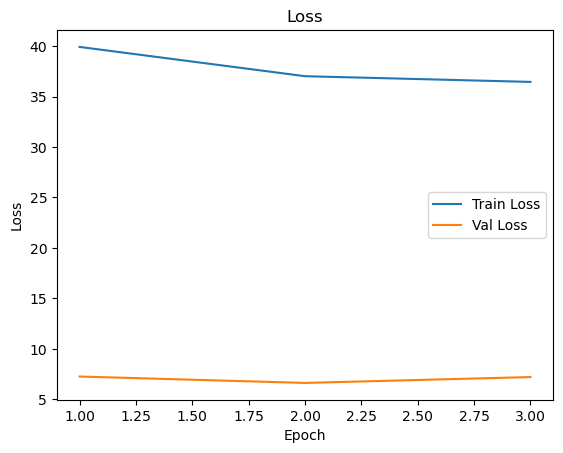

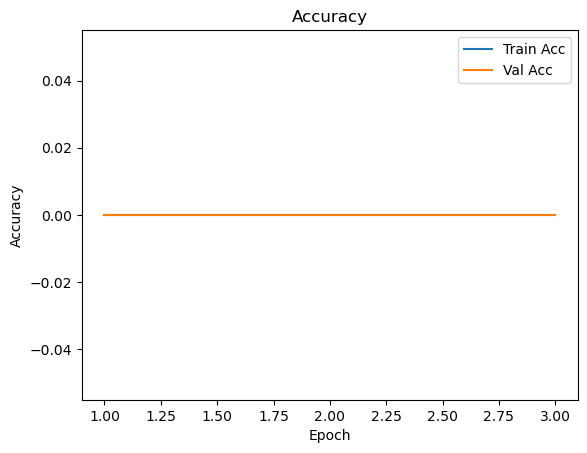

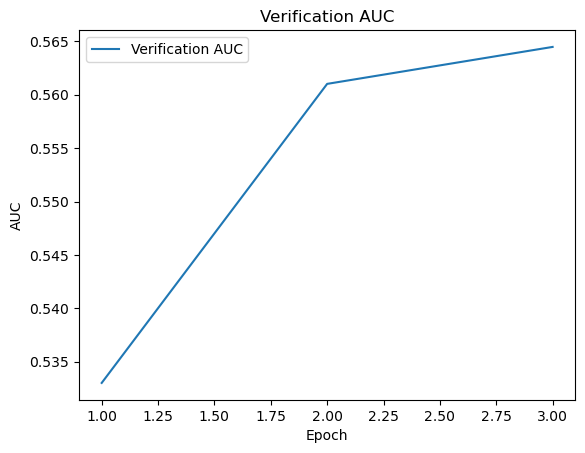

In [2]:
# === Everything in ONE cell: train ArcFace on LFW, log to files, and plot ===

# ---- Imports ----
import os, sys, math, time, csv, json, argparse
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm import tqdm

from IPython import get_ipython
ip = get_ipython()
if ip:
    ip.run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

# ---- ArcFace head ----
class ArcMarginProduct(nn.Module):
    def __init__(self, in_feat, out_feat, s=64.0, m=0.50, easy_margin=False):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(out_feat, in_feat))
        nn.init.xavier_uniform_(self.weight)
        self.s = s
        self.m = m
        self.easy_margin = easy_margin
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, emb, label):
        emb = F.normalize(emb, p=2, dim=1)
        W = F.normalize(self.weight, p=2, dim=1)
        cosine = F.linear(emb, W).clamp(-1, 1)
        sine = torch.sqrt((1.0 - cosine ** 2).clamp(0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        onehot = torch.zeros_like(cosine)
        onehot.scatter_(1, label.view(-1, 1), 1.0)
        logits = onehot * phi + (1.0 - onehot) * cosine
        logits *= self.s
        return logits

# ---- Backbone ----
class FaceNet(nn.Module):
    def __init__(self, embedding_dim=128, pretrained=False):
        super().__init__()
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT if pretrained else None
        )
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.embed = nn.Linear(in_features, embedding_dim, bias=False)
        self.bn = nn.BatchNorm1d(embedding_dim)

    def forward(self, x):
        x = self.backbone(x)
        x = self.embed(x)
        x = self.bn(x)
        return x

# ---- Utilities ----
def set_seed(seed=42):
    import random
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

def build_transforms(img_size):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])

def _maybe_fix_nested_root(root):
    inner = Path(root) / "lfw-deepfunneled"
    if inner.exists() and inner.is_dir():
        subdirs = [p for p in inner.iterdir() if p.is_dir()]
        if len(subdirs) > 0:
            return str(inner)
    return root

def split_by_identity(dataset: ImageFolder, train_id_frac=0.8, min_images_per_id=2, seed=42):
    by_class = defaultdict(list)
    for idx, (_, cls) in enumerate(dataset.samples):
        by_class[cls].append(idx)

    valid_classes = [c for c, idxs in by_class.items() if len(idxs) >= min_images_per_id]
    if len(valid_classes) == 0:
        return [], [], [], []

    rng = np.random.default_rng(seed)
    rng.shuffle(valid_classes)
    split_point = max(1, int(len(valid_classes) * train_id_frac))
    train_classes = set(valid_classes[:split_point])
    val_classes   = set(valid_classes[split_point:]) or set(valid_classes[-1:])

    train_idx, val_idx = [], []
    for c, idxs in by_class.items():
        if c in train_classes: train_idx.extend(idxs)
        elif c in val_classes: val_idx.extend(idxs)
    return train_idx, val_idx, sorted(list(train_classes)), sorted(list(val_classes))

class RemapSubset(Dataset):
    def __init__(self, base: ImageFolder, indices, class_remap=None):
        self.base = base
        self.indices = list(indices)
        self.class_remap = class_remap  # dict old->new or None

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y = self.base[self.indices[i]]
        if self.class_remap is not None:
            y = self.class_remap[y]
        return x, y

def make_loaders(img_size=112, batch_size=64, root="./archive/lfw-deepfunneled",
                 train_id_frac=0.8, min_images_per_id=2, max_train_ids=None,
                 num_workers=0, seed=42):
    tfm = build_transforms(img_size)
    root = _maybe_fix_nested_root(root)
    full_dataset = ImageFolder(root=root, transform=tfm)
    if len(full_dataset) == 0:
        raise RuntimeError(f"No images under {root}")

    train_idx, val_idx, train_classes, val_classes = split_by_identity(
        full_dataset, train_id_frac=train_id_frac, min_images_per_id=min_images_per_id, seed=seed
    )

    if train_classes and max_train_ids is not None and len(train_classes) > max_train_ids:
        rng = np.random.default_rng(seed)
        keep = set(rng.choice(train_classes, size=max_train_ids, replace=False))
        train_idx = [i for i in train_idx if full_dataset.samples[i][1] in keep]
        train_classes = sorted(list(keep))

    if len(train_idx) == 0:
        print("[WARN] Identity split empty; falling back to random image split.")
        n_total = len(full_dataset)
        n_train = max(1, int(0.8 * n_total))
        n_val = n_total - n_train
        gen = torch.Generator().manual_seed(seed)
        train_subset, val_subset = torch.utils.data.random_split(full_dataset, [n_train, n_val], generator=gen)
        num_train_classes = len(full_dataset.classes)
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=False)
        val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False,num_workers=num_workers, pin_memory=False)
        print(f"[INFO] Random split: train images={len(train_subset)}, val images={len(val_subset)}")
        return full_dataset, train_loader, val_loader, num_train_classes, list(range(len(val_subset)))

    class_remap = {old: new for new, old in enumerate(train_classes)}
    train_set = RemapSubset(full_dataset, train_idx, class_remap=class_remap)
    val_set   = RemapSubset(full_dataset, val_idx, class_remap=None)

    print(f"[INFO] Train identities: {len(train_classes)} | Train images: {len(train_idx)}")
    print(f"[INFO] Val   identities: {len(val_classes)} | Val   images: {len(val_idx)}")

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=False)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=False)
    num_train_classes = len(train_classes)
    return full_dataset, train_loader, val_loader, num_train_classes, val_idx

# ---- Verification pairs ----
def build_verification_pairs(dataset: ImageFolder, val_indices, n_pos=2000, n_neg=2000, seed=42):
    rng = np.random.default_rng(seed)
    by_class = defaultdict(list)
    for idx in val_indices:
        _, c = dataset.samples[idx]
        by_class[c].append(idx)
    classes = [c for c, idxs in by_class.items() if len(idxs) >= 2]
    if len(classes) == 0:
        raise RuntimeError("No validation identities with >=2 images to make positive pairs.")
    pos_pairs, neg_pairs = [], []
    for _ in range(n_pos):
        c = rng.choice(classes)
        i1, i2 = rng.choice(by_class[c], size=2, replace=False)
        pos_pairs.append((i1, i2, 1))
    val_classes = list(by_class.keys())
    for _ in range(n_neg):
        c1, c2 = rng.choice(val_classes, size=2, replace=False)
        i1 = rng.choice(by_class[c1]); i2 = rng.choice(by_class[c2])
        neg_pairs.append((i1, i2, 0))
    return pos_pairs + neg_pairs

@torch.no_grad()
def evaluate_verification(model, dataset: ImageFolder, pairs, batch_size=128, device="cpu"):
    model.eval()
    uniq = sorted({i for (i,_,_) in pairs} | {j for (_,j,_) in pairs})
    imgs = torch.stack([dataset[inx][0] for inx in uniq], dim=0).to(device)
    embs = []
    for s in range(0, len(imgs), batch_size):
        embs.append(model(imgs[s:s+batch_size]))
    embs = F.normalize(torch.cat(embs, dim=0), p=2, dim=1)
    idx_to_row = {idx: r for r, idx in enumerate(uniq)}
    sims, labels = [], []
    for i, j, lab in pairs:
        e1 = embs[idx_to_row[i]]; e2 = embs[idx_to_row[j]]
        sims.append(float(torch.sum(e1 * e2))); labels.append(lab)
    sims = np.array(sims); labels = np.array(labels)
    auc = roc_auc_score(labels, sims)
    thresholds = np.linspace(-1, 1, 4001)
    accs = []
    for th in thresholds:
        preds = (sims >= th).astype(int)
        accs.append(accuracy_score(labels, preds))
    k = int(np.argmax(accs))
    return auc, accs[k], thresholds[k]

# ---- Train / Eval ----
def train_epoch(model, head, loader, optimizer, device):
    model.train(); head.train()
    loss_meter, correct, total = 0.0, 0, 0
    for imgs, targets in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device); targets = targets.to(device)
        optimizer.zero_grad()
        emb = model(imgs)
        logits = head(emb, targets)
        loss = F.cross_entropy(logits, targets)
        loss.backward(); optimizer.step()
        loss_meter += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == targets).sum().item()
        total += imgs.size(0)
    return loss_meter/total, correct/total

@torch.no_grad()
def eval_cls(model, head, loader, device):
    model.eval(); head.eval()
    loss_meter, correct, total = 0.0, 0, 0
    for imgs, targets in tqdm(loader, desc="Eval", leave=False):
        imgs = imgs.to(device); targets = targets.to(device)
        emb = model(imgs)
        emb = F.normalize(emb, p=2, dim=1)
        W = F.normalize(head.weight, p=2, dim=1)
        logits = F.linear(emb, W) * head.s  # no margin
        valid = targets < logits.shape[1]
        if valid.sum() == 0: 
            continue
        logits = logits[valid]; targets = targets[valid]
        loss = F.cross_entropy(logits, targets)
        bs = int(valid.sum().item())
        loss_meter += loss.item() * bs
        preds = logits.argmax(1)
        correct += (preds == targets).sum().item()
        total += bs
    return (loss_meter / max(1,total)), (correct / max(1,total))

# ---- Main with file logging ----
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-root", type=str, default="./archive/lfw-deepfunneled")
    parser.add_argument("--epochs", type=int, default=1)
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--img-size", type=int, default=96)
    parser.add_argument("--embedding-dim", type=int, default=128)
    parser.add_argument("--arc-s", type=float, default=64.0)
    parser.add_argument("--arc-m", type=float, default=0.50)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--pretrained-backbone", action="store_true")
    parser.add_argument("--max-train-ids", type=int, default=400)
    parser.add_argument("--pairs-per-type", type=int, default=2000)
    parser.add_argument("--min-images-per-id", type=int, default=2)
    parser.add_argument("--num-workers", type=int, default=0, help="Use 0 on Windows to avoid pickling issues")
    parser.add_argument("--out-prefix", type=str, default="lfw_run")  # NEW: file outputs
    args = parser.parse_args()

    set_seed(args.seed)
    device = torch.device("cpu")

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "auc": []}

    dataset, train_loader, val_loader, num_train_classes, val_indices = make_loaders(
        img_size=args.img_size,
        batch_size=args.batch_size,
        root=args.data_root,
        train_id_frac=0.8,
        min_images_per_id=args.min_images_per_id,
        max_train_ids=args.max_train_ids,
        num_workers=args.num_workers,
        seed=args.seed
    )

    model = FaceNet(embedding_dim=args.embedding_dim, pretrained=args.pretrained_backbone).to(device)
    head  = ArcMarginProduct(in_feat=args.embedding_dim, out_feat=num_train_classes,
                             s=args.arc_s, m=args.arc_m).to(device)

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(head.parameters()),
        lr=args.lr, weight_decay=args.weight_decay
    )

    try:
        pairs = build_verification_pairs(
            dataset, val_indices,
            n_pos=args.pairs_per_type, n_neg=args.pairs_per_type,
            seed=args.seed
        )
        have_pairs = True
    except RuntimeError as e:
        print(f"[WARN] No verification pairs: {e}")
        have_pairs = False

    out_prefix = args.out_prefix
    metrics_csv = Path(f"{out_prefix}_metrics.csv")
    history_json = Path(f"{out_prefix}_history.json")
    ckpt_best = Path(f"{out_prefix}_best.pt")
    ckpt_last = Path(f"{out_prefix}_last.pt")

    best_auc = -float("inf")

    with metrics_csv.open("w", newline="") as f_csv:
        writer = csv.writer(f_csv)
        writer.writerow(["epoch","train_loss","train_acc","val_loss","val_acc","auc","best_acc","best_thr","seconds"])
        f_csv.flush()
        try: os.fsync(f_csv.fileno())
        except: pass

        for epoch in range(1, args.epochs + 1):
            t0 = time.time()
            tr_loss, tr_acc = train_epoch(model, head, train_loader, optimizer, device)
            va_loss, va_acc = eval_cls(model, head, val_loader, device)

            if have_pairs:
                auc, best_acc, best_th = evaluate_verification(
                    model, dataset, pairs, batch_size=max(64, args.batch_size), device=device
                )
            else:
                auc, best_acc, best_th = float("nan"), float("nan"), float("nan")

            # in-memory
            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["val_loss"].append(va_loss)
            history["val_acc"].append(va_acc)
            history["auc"].append(auc)

            dt = time.time() - t0
            print(f"[Epoch {epoch:02d}] "
                  f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} "
                  f"val_loss={va_loss:.4f} val_acc={va_acc:.3f} "
                  f"VERIF: AUC={auc:.4f} bestACC={best_acc:.3f} @thr={best_th:.3f} "
                  f"({dt:.1f}s)")

            # CSV append
            writer.writerow([epoch, tr_loss, tr_acc, va_loss, va_acc, auc, best_acc, best_th, dt])
            f_csv.flush()
            try: os.fsync(f_csv.fileno())
            except: pass

            # save "last" each epoch
            torch.save({
                "model": model.state_dict(),
                "head": head.state_dict(),
                "args": vars(args),
                "num_train_classes": num_train_classes,
                "last_epoch": epoch,
                "best_auc": float(best_auc if best_auc != -float("inf") else float("nan")),
            }, ckpt_last)

            # save "best" on improvement
            if have_pairs and (np.isfinite(auc) and auc > best_auc):
                best_auc = auc
                torch.save({
                    "model": model.state_dict(),
                    "head": head.state_dict(),
                    "args": vars(args),
                    "num_train_classes": num_train_classes,
                    "best_auc": best_auc
                }, ckpt_best)
                print(f"  ↳ Saved new best checkpoint: {ckpt_best} (AUC {best_auc:.4f})")

    # dump full history json
    with history_json.open("w") as f_js:
        json.dump(history, f_js, indent=2)

    print(f"[INFO] Wrote {metrics_csv.name}, {history_json.name}, {ckpt_last.name}"
          + (f", {ckpt_best.name}" if np.isfinite(best_auc) else ""))
    print("Done.")
    return history

# ---- Run training and plot (configure args here) ----
sys.argv = [
    "notebook",
    "--epochs", "3",              # change as needed
    "--batch-size", "32",
    "--img-size", "96",
    "--data-root", "./archive/lfw-deepfunneled",
    "--num-workers", "0",
    "--out-prefix", "lfw_run",    # files next to this notebook
    # "--pretrained-backbone",    # uncomment to use ImageNet-pretrained ResNet18
]
hist = main()

# ---- Plot from CSV (preferred), fallback to in-memory history ----
def plot_from_lists(epochs, train_loss, val_loss, train_acc, val_acc, auc_list):
    plt.figure(); plt.plot(epochs, train_loss, label="Train Loss"); plt.plot(epochs, val_loss, label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss"); plt.legend(); plt.show()

    plt.figure(); plt.plot(epochs, train_acc, label="Train Acc"); plt.plot(epochs, val_acc, label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy"); plt.legend(); plt.show()

    if any(x is not None and not (isinstance(x, float) and math.isnan(x)) for x in auc_list):
        plt.figure(); plt.plot(epochs, auc_list, label="Verification AUC")
        plt.xlabel("Epoch"); plt.ylabel("AUC"); plt.title("Verification AUC"); plt.legend(); plt.show()

csv_path = "lfw_run_metrics.csv"
if os.path.exists(csv_path):
    try:
        import pandas as pd
        df = pd.read_csv(csv_path)
        epochs = df["epoch"].tolist()
        plot_from_lists(
            epochs,
            df["train_loss"].tolist(),
            df["val_loss"].tolist(),
            df["train_acc"].tolist(),
            df["val_acc"].tolist(),
            df["auc"].tolist(),
        )
    except Exception as e:
        print(f"[WARN] pandas plotting fallback due to: {e}")
        ep = list(range(1, len(hist['train_loss'])+1))
        plot_from_lists(ep, hist['train_loss'], hist['val_loss'], hist['train_acc'], hist['val_acc'], hist['auc'])
else:
    ep = list(range(1, len(hist['train_loss'])+1))
    plot_from_lists(ep, hist['train_loss'], hist['val_loss'], hist['train_acc'], hist['val_acc'], hist['auc'])

